<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Entangle006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

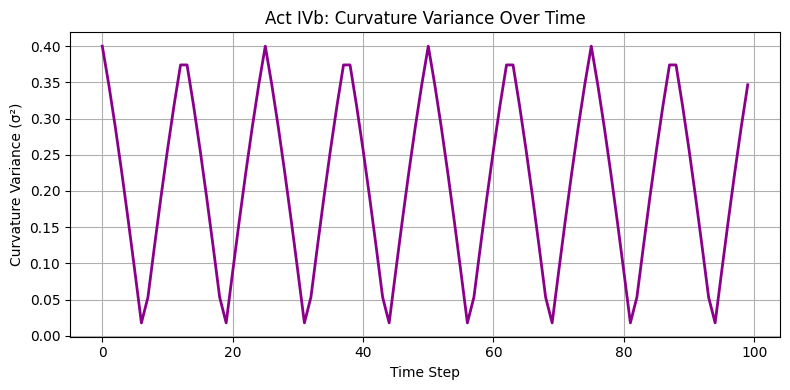

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Build Bipartite Network
# -------------------------------
def build_boundary_bulk_network(boundary_size=8, bulk_size=32):
    G = nx.Graph()
    boundary_nodes = [f"B{i}" for i in range(boundary_size)]
    bulk_nodes = [f"U{i}" for i in range(bulk_size)]

    G.add_nodes_from(boundary_nodes, region='boundary')
    G.add_nodes_from(bulk_nodes, region='bulk')

    for b in boundary_nodes:
        connections = np.random.choice(bulk_nodes, size=4, replace=False)
        for u in connections:
            G.add_edge(b, u)

    for i in range(bulk_size):
        for j in range(i + 1, bulk_size):
            if np.random.rand() < 0.05:
                G.add_edge(f"U{i}", f"U{j}")

    return G

# -------------------------------
# Step 2: Dynamic δ(t) and κ(t)
# -------------------------------
def update_weights(G, t, δ_max=1.0, κ_max=1.0):
    δ_t = δ_max * np.sin(2 * np.pi * t / 50)
    κ_t = κ_max * np.cos(2 * np.pi * t / 50)
    for node in G.nodes:
        region = G.nodes[node]['region']
        G.nodes[node]['delta'] = δ_t if region == 'boundary' else 0.0
        G.nodes[node]['kappa'] = κ_t if region == 'bulk' else 0.0

# -------------------------------
# Step 3: Compute Curvature
# -------------------------------
def compute_curvature(G):
    return [np.abs(G.nodes[node]['delta'] - G.nodes[node]['kappa']) for node in G.nodes]

# -------------------------------
# Step 4: Track Curvature Variance
# -------------------------------
def track_curvature_variance(G, frames=100):
    variances = []
    for t in range(frames):
        update_weights(G, t)
        curvature = compute_curvature(G)
        variance = np.std(curvature)
        variances.append(variance)
    return variances

# -------------------------------
# Step 5: Plot Variance Over Time
# -------------------------------
def plot_variance(variances):
    plt.figure(figsize=(8, 4))
    plt.plot(variances, color='darkmagenta', linewidth=2)
    plt.title("Act IVb: Curvature Variance Over Time")
    plt.xlabel("Time Step")
    plt.ylabel("Curvature Variance (σ²)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -------------------------------
# Step 6: Run the Ritual
# -------------------------------
G = build_boundary_bulk_network()
variances = track_curvature_variance(G)
plot_variance(variances)
